In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [ ]:
import polars as pl
import altair as alt

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
from functools import partial
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.evaluation import evaluate
from statsforecast.utils import ConformalIntervals
from utilsforecast.losses import mase, rmsse, rmae, mqloss
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    SeasonalNaive,
    AutoCES,
    AutoMFLES,
    AutoTBATS,
    AutoTheta,
)
from statsforecast.adapters.prophet import AutoARIMAProphet
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, NHITS, BiTCN, RNN
from neuralforecast.auto import AutoNHITS
from neuralforecast.losses.pytorch import DistributionLoss, MAE
from typing import Callable, Literal, Any, Mapping, Optional, Iterable, Sequence

# import calendar

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from datetime import date, timedelta
from typing import Optional

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [ ]:
gregorian_year_days = int(365.25)
gregorian_year_weeks = int(gregorian_year_days / 7)
hijri_year_days = int(354.37)
hijri_year_weeks = 51

In [ ]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [ ]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

In [ ]:
importlib.reload(lib)
base_df = fields.pipe(
    lib.aggregate_by_date,
    freq="7d",
    value_col="weight_kg",
    date_col="Date_depot",
    total_col="total_weight_kg",
    count_col="count",
    mean_col="mean_weight_kg",
    std_col="std_weight_kg",
    extra_cols=lib.make_relative_hist_cols(
        "weight_kg", list(range(32)) + [np.inf], "sum"
    ),
)

# base_df_daily = fields.pipe(
#     lib.aggregate_by_date,
#     freq="1d",
#     value_col="weight_kg",
#     date_col="Date_depot",
#     total_col="total_weight_kg",
#     count_col="count",
#     mean_col="mean_weight_kg",
#     std_col="std_weight_kg",
#     extra_cols=lib.make_relative_hist_cols(
#         "weight_kg", list(range(32)) + [np.inf], "sum"
#     ),
# )

chart = (
    alt.Chart(base_df)
    .mark_line(point=True)
    .encode(
        x="Date_depot:T",
        y=alt.Y("count:Q", scale=alt.Scale(zero=False)),
        tooltip=["Date_depot:T"]
    )
    .properties(width=1100, title="Weekly Mean Weight")
)
chart

alt.Chart(...)

In [ ]:
def transform_timeseries(
    df: pl.DataFrame,
    cols: pl.Expr | list[str] | str = "y",
) -> pl.DataFrame:
    if isinstance(cols, str | list):
        cols = pl.col(cols)
    return df.with_columns(cols.log1p())


def untransform_timeseries(
    df: pl.DataFrame,
    cols: pl.Expr | list[str] | str = pl.exclude("unique_id", "ds"),
) -> pl.DataFrame:
    if isinstance(cols, str | list):
        cols = pl.col(cols)
    return df.with_columns(cols.exp() - 1)


def calculate_max_n_windows(N, h, season_length, step_size):
    return (N - h - season_length - 1) // step_size


# def add_weekday_dummies(df):
#     return df.with_columns(pl.col("ds").dt.weekday().alias("weekday")).to_dummies(
#         columns=["weekday"],
#         drop_first=True,
#     )


# def make_X_df_daily(
#     h: int,
#     start: date = base_df_daily["Date_depot"].sort()[-1] + timedelta(days=1),
# ) -> pl.DataFrame:
#     return pl.DataFrame(
#         {
#             "ds": pl.date_range(
#                 start=start,
#                 end=start + timedelta(days=h - 1),
#                 eager=True,
#             ),
#             "unique_id": "all",
#         }
#     ).pipe(add_weekday_dummies)

In [ ]:
# df_daily = (
#     base_df_daily.select(
#         ds=pl.col("Date_depot"),
#         y=pl.col("count"),
#         unique_id=pl.lit("all"),
#         # available_mask=pl.col("count") != 0,
#     )
#     .pipe(add_weekday_dummies)
#     .pipe(transform_timeseries)
# )

df = base_df.select(
    ds=pl.col("Date_depot"),
    y=pl.col("count"),
    unique_id=pl.lit("all"),
).pipe(transform_timeseries)


levels: list[int] = [80, 95]
h = 4
# intervals_daily = ConformalIntervals(h=h, n_windows=min(10, len(df_daily) // h))
intervals = ConformalIntervals(h=h, n_windows=min(10, len(df) // h))
cv_step_size = 10
# cv_n_windows_daily = calculate_max_n_windows(
#     len(df_daily), h, hijri_year_weeks, cv_step_size
# )
cv_n_windows = calculate_max_n_windows(
    len(df), h, hijri_year_weeks, cv_step_size
)

In [ ]:
sf = StatsForecast(
    freq="1w",
    n_jobs=-1,
    models=[
        SeasonalNaive(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals, # buggy
        ),
        AutoETS(
            model="AAA",
            damped=True,
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals,  # unneeded
        ),
        AutoARIMA(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals,  # unneeded
        ),
        AutoCES(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals,  # unneeded
        ),
        AutoMFLES(
            test_size=50,
            season_length=hijri_year_weeks,
            prediction_intervals=intervals,  # necessary
        ),
        AutoTBATS(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals,  # not allowed
        ),
        AutoTheta(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals,  # unneeded
        ),
    ],
)

sf.fit(df=df)  # pyright: ignore[reportArgumentType]

StatsForecast(models=[SeasonalNaive,AutoETS,AutoARIMA,CES,AutoMFLES,AutoTBATS,AutoTheta])

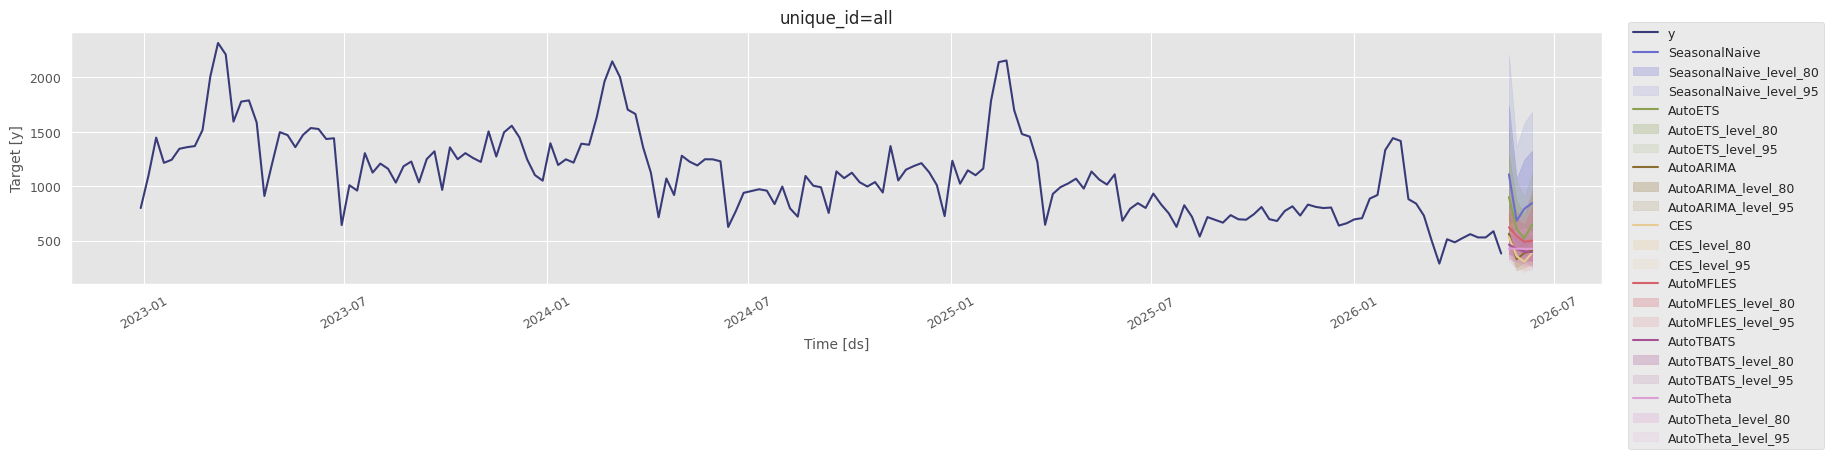

In [ ]:
fc: pl.DataFrame = sf.predict(
    h=h,
    level=levels,
)  # pyright: ignore[reportAssignmentType]

sf.plot(
    df.pipe(untransform_timeseries).to_pandas(),
    fc.pipe(untransform_timeseries).to_pandas(),
    level=levels,  # pyright: ignore[reportArgumentType]
)

In [ ]:
cv_df = sf.cross_validation(
    h=h,
    df=df.to_pandas(),
    n_windows=cv_n_windows,
    step_size=cv_step_size,
    # level=levels,
)

transformed_cv_df = pl.DataFrame(cv_df).pipe(
    untransform_timeseries,
    pl.exclude("unique_id", "ds", "cutoff"),
)

cv_evaluation = evaluate(
    transformed_cv_df,
    train_df=df.to_pandas(),
    metrics=[
        # partial(mase, seasonality=hijri_year_weeks),
        # partial(rmsse, seasonality=hijri_year_weeks),
        partial(rmae, baseline="SeasonalNaive"),
        # mqloss
    ],
    # level=levels,
)
print(pl.DataFrame(cv_evaluation))

shape: (12, 10)
┌───────────┬─────────────────────┬────────────────────┬───────────────┬──────────┬───────────┬──────────┬───────────┬───────────┬───────────┐
│ unique_id ┆ cutoff              ┆ metric             ┆ SeasonalNaive ┆ AutoETS  ┆ AutoARIMA ┆ CES      ┆ AutoMFLES ┆ AutoTBATS ┆ AutoTheta │
│ ---       ┆ ---                 ┆ ---                ┆ ---           ┆ ---      ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---       │
│ str       ┆ datetime[ms]        ┆ str                ┆ f64           ┆ f64      ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═════════════════════╪════════════════════╪═══════════════╪══════════╪═══════════╪══════════╪═══════════╪═══════════╪═══════════╡
│ all       ┆ 2024-03-07 00:00:00 ┆ rmae_SeasonalNaive ┆ 1.0           ┆ 1.123343 ┆ 0.472917  ┆ 2.208268 ┆ 0.911099  ┆ 1.037484  ┆ 1.933328  │
│ all       ┆ 2024-05-16 00:00:00 ┆ rmae_SeasonalNaive ┆ 1.0           ┆ 0.950016 ┆ 0.46182   ┆ 0.438315 ┆ 0.447636  ┆ 0.43061

In [ ]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric")
    .agg(pl.exclude("unique_id", "cutoff", "metric").pipe(lib.exp_weighted_mean, 3))
    .unpivot(index="metric", variable_name="model", value_name="score")
    .sort("score")
)

shape: (7, 2)
┌───────────────┬──────────┐
│ model         ┆ rmae     │
│ ---           ┆ ---      │
│ str           ┆ f64      │
╞═══════════════╪══════════╡
│ SeasonalNaive ┆ 1.0      │
│ AutoETS       ┆ 0.875047 │
│ AutoARIMA     ┆ 0.397333 │
│ CES           ┆ 0.425647 │
│ AutoMFLES     ┆ 0.595519 │
│ AutoTBATS     ┆ 0.521881 │
│ AutoTheta     ┆ 0.556536 │
└───────────────┴──────────┘


In [ ]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric")
    .agg(pl.exclude("unique_id", "cutoff", "metric").mean())
    .unpivot(index="metric", variable_name="model", value_name="score")
    .sort("score")
)

shape: (7, 3)
┌────────────────────┬───────────────┬──────────┐
│ metric             ┆ model         ┆ score    │
│ ---                ┆ ---           ┆ ---      │
│ str                ┆ str           ┆ f64      │
╞════════════════════╪═══════════════╪══════════╡
│ rmae_SeasonalNaive ┆ AutoARIMA     ┆ 0.463273 │
│ rmae_SeasonalNaive ┆ AutoTBATS     ┆ 0.613759 │
│ rmae_SeasonalNaive ┆ CES           ┆ 0.619418 │
│ rmae_SeasonalNaive ┆ AutoMFLES     ┆ 0.701816 │
│ rmae_SeasonalNaive ┆ AutoTheta     ┆ 0.780526 │
│ rmae_SeasonalNaive ┆ AutoETS       ┆ 0.950324 │
│ rmae_SeasonalNaive ┆ SeasonalNaive ┆ 1.0      │
└────────────────────┴───────────────┴──────────┘


In [ ]:
long_df = pl.DataFrame(cv_evaluation).unpivot(
    index=["unique_id", "cutoff", "metric"],
    on=pl.selectors.exclude(["unique_id", "cutoff", "metric"]),
    variable_name="model",
    value_name="value",
)

chart = (
    alt.Chart(long_df.to_pandas())
    .mark_line(point=True)
    .encode(
        x=alt.X("cutoff:T", title="Cutoff"),
        y=alt.Y("value:Q", title="RMAE"),
        color=alt.Color("model:N", title="Model"),
        tooltip=["cutoff:T", "model:N", "value:Q"],
    )
    .properties(width=800, height=400, title="RMAE over Cross-validation windows by model")
)

chart

alt.Chart(...)

In [ ]:
# best_config = {
#     "h": 10,
#     "n_pool_kernel_size": [2, 2, 2],
#     "n_freq_downsample": [24, 12, 1],
#     "learning_rate": 0.00017565392237572106,
#     "scaler_type": None,
#     "max_steps": 1400.0,
#     "batch_size": 256,
#     "windows_batch_size": 1024,
#     "loss": MAE(),
#     "random_seed": 17,
#     "input_size": 20,
#     "step_size": 1,
#     "valid_loss": MAE(),
# }
best_model_h_4 = {
    "h": 4,
    "n_pool_kernel_size": [2, 2, 2],
    "n_freq_downsample": [168, 24, 1],
    "learning_rate": 0.0038527230372795897,
    "scaler_type": "standard",
    "max_steps": 600.0,
    "batch_size": 64,
    "windows_batch_size": 256,
    "loss": MAE(),
    "random_seed": 13,
    "input_size": 16,
    "step_size": 4,
    "valid_loss": MAE(),
}

In [ ]:
# auto_nhits = nf.models[0]   # AutoNHITS instance

# best_config = auto_nhits.results.get_best_result().config
# print(best_config)

Seed set to 17


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | valid_loss   | MAE           | 0      | train
2 | padder_train | ConstantPad1d | 0      | train
3 | scaler       | TemporalNorm  | 0      | train
4 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
9.876     Total estimated model params size (MB)
35        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1400.0` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

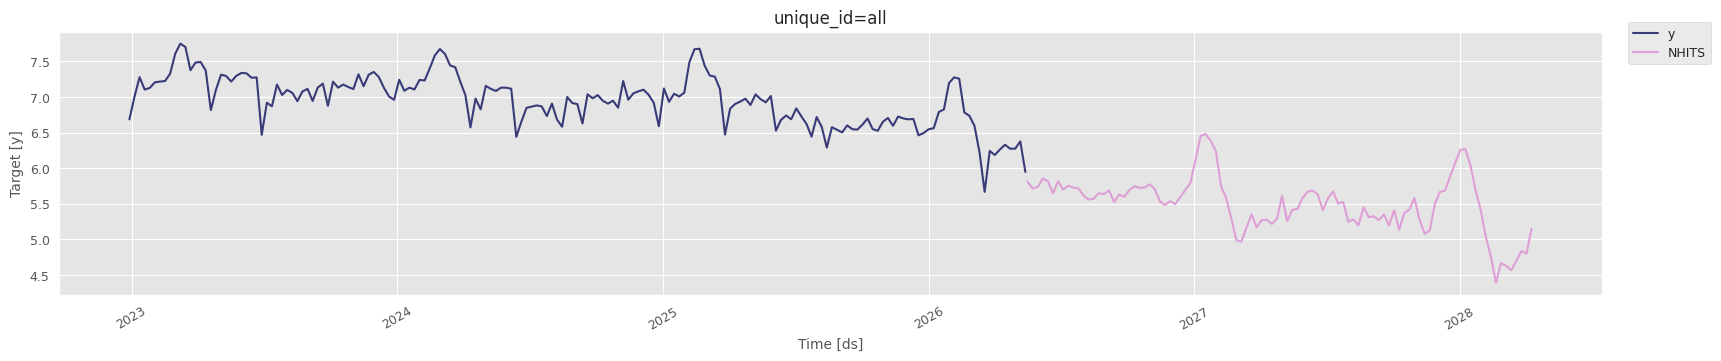

: 

In [ ]:
nf = NeuralForecast(
    models=[
        # AutoNHITS(
        #     h=4,
        # ),
        NHITS(
            **{
                "h": 100,
                "n_pool_kernel_size": [2, 2, 2],
                "n_freq_downsample": [24, 12, 1],
                "learning_rate": 0.00017565392237572106,
                "scaler_type": None,
                "max_steps": 1400.0,
                "batch_size": 256,
                "windows_batch_size": 1024,
                "loss": MAE(),
                "random_seed": 17,
                "input_size": 20,
                "step_size": 1,
                "valid_loss": MAE(),
            }
        ),
    ],
    freq="W",
)
nf.fit(df=df.to_pandas())
fc = nf.predict()
sf.plot(df.to_pandas(), fc)

In [ ]:
cv_df_nf = nf.cross_validation(
    h=h,
    df=df.to_pandas(),
    n_windows=cv_n_windows,
    step_size=cv_step_size,
    # level=levels,
)

# transformed_cv_df = pl.DataFrame(cv_df).pipe(
#     untransform_timeseries,
#     pl.exclude("unique_id", "ds", "cutoff"),
# )

cv_evaluation_nf = evaluate(
    cv_df_nf,
    train_df=df.to_pandas(),
    metrics=[
        # partial(mase, seasonality=hijri_year_weeks),
        # partial(rmsse, seasonality=hijri_year_weeks),
        partial(rmae, baseline="SeasonalNaive"),
        # mqloss
    ],
    # level=levels,
)
print(pl.DataFrame(cv_evaluation_nf))

(raylet) Warning: The actor ImplicitFunc is very large (18 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.


(pid=1167787) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=1167787)   actor_class = pickle.loads(pickled_class)
(pid=1167787) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/_private/function_manager.py:677: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
(pid=1167787)   actor_class = pickle.loads(pickled_class)
(_train_tune pid=1167787) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=1167

Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]                             


(_train_tune pid=1167787) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s, v_num=0, train_loss_step=1.39e+7, train_loss_epoch=1.97e+7]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(_train_tune pid=1167787) 
Epoch 144:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=1.37e+9, train_loss_epoch=1.37e+9, valid_loss=7.12e+7]        


...

Epoch 176:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=9.82e+10, train_loss_epoch=9.82e+10, valid_loss=7.12e+7]        


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [ ]:
fc = nf.predict(h=100)
sf.plot(df.to_pandas(), fc)

In [ ]:
# auto_model = nf.models[0]
# best_config = auto_model.results.get_best_result().config

{'h': 10,
 'n_pool_kernel_size': [2, 2, 2],
 'n_freq_downsample': [24, 12, 1],
 'learning_rate': 0.00017565392237572106,
 'scaler_type': None,
 'max_steps': 1400.0,
 'batch_size': 256,
 'windows_batch_size': 1024,
 'loss': MAE(),
 'random_seed': 17,
 'input_size': 20,
 'step_size': 1,
 'valid_loss': MAE()}